- **[0]모듈 로딩**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.neighbors import KNeighborsClassifier

- **[1]데이터 준비**

In [25]:
DATA_FILE = '../Data/Numbers/iris.csv'
df = pd.read_csv(DATA_FILE)

- **[2]데이터 전처리**

In [26]:
df['variety'] = df['variety'].astype('category')

- **[3]학습용|테스트용 데이터셋 준비**

In [27]:
# df.columns[:-1] : 마지막 열을 제외한 모든 열 선택 (입력 특성)
feature = df[df.columns[:-1]]

# df.columns[-1] : 마지막 열 선택 (예측 대상 레이블)
target = df[df.columns[-1]]

# train_test_split() : 데이터를 학습용(train)과 테스트용(test)으로 분리하는 함수
x_train, x_test, y_train, y_test = train_test_split(
    feature,           # 입력 특성 데이터
    target,            # 정답 레이블 데이터
    test_size=0.2,     # 전체 데이터 중 20%를 테스트셋으로 분리
    random_state=10,   # 재현성을 위한 난수 시드 고정 (같은 값이면 항상 동일하게 분리)
    stratify=target    # 클래스 비율을 원본과 동일하게 유지하며 분리 (불균형 데이터에 중요)
)

- **[4]하이퍼파라미터 튜닝 및 교차 검증**
    * 모든 파라미터 조합 튜닝
    * 선택 파라미터 조합 튜닝
    * 2개 결과 비교

In [28]:
k_model = KNeighborsClassifier()

# 탐색할 하이퍼파라미터 조합 딕셔너리
param_dict = {
    'n_neighbors': range(1,50,2),                          # K값: 1~49 홀수 (25가지)
    'p': [1, 2],                                           # 거리 계산 방식: 1=맨해튼, 2=유클리드
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'] # 최근접 이웃 탐색 알고리즘
}
# => 전체 조합: 25 × 2 × 4 = 200가지

# StratifiedKFold : 클래스 비율을 유지하면서 데이터를 K개의 폴드로 나누는 교차검증 방식
skFold = StratifiedKFold(n_splits=5,      # 데이터를 5개의 폴드로 분할
                         shuffle=True,     # 분할 전 데이터를 무작위로 섞음
                         random_state=10)  # 재현성을 위한 난수 시드 고정

# GridSearchCV : param_grid의 모든 파라미터 조합을 전수 탐색하여 최적 조합을 찾는 함수
gs_model = GridSearchCV(
    k_model,                    # 튜닝할 기본 모델
    param_grid=param_dict,      # 탐색할 파라미터 딕셔너리 (전체 200가지 조합 탐색)
    cv=skFold,                  # 교차검증 방식 (StratifiedKFold)
    return_train_score=True,    # 학습 데이터 점수도 함께 저장
    n_jobs=-1                   # 모든 CPU 코어를 병렬 사용 (속도 향상)
)
gs_model.fit(x_train, y_train)

cv_result = pd.DataFrame(gs_model.cv_results_)  # 전체 조합의 교차검증 결과를 DataFrame으로 변환
gs_best = gs_model.best_estimator_              # 최적 파라미터로 학습된 모델 추출

In [ ]:
k_model = KNeighborsClassifier()

# 탐색할 하이퍼파라미터 조합 딕셔너리 (GridSearchCV와 동일한 탐색 범위)
param_dict = {
    'n_neighbors': range(1,50,2),                          # K값: 1~49 홀수 (25가지)
    'p': [1, 2],                                           # 거리 계산 방식: 1=맨해튼, 2=유클리드
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'] # 최근접 이웃 탐색 알고리즘
}
# => 전체 조합: 25 × 2 × 4 = 200가지

skFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

# RandomizedSearchCV : param_distributions에서 n_iter개의 조합만 랜덤 샘플링하여 탐색하는 함수
# GridSearchCV 대비 탐색 시간 단축 (단, 일부 조합은 탐색하지 않음)
rs_model = RandomizedSearchCV(
    k_model,                          # 튜닝할 기본 모델
    param_distributions=param_dict,   # 탐색할 파라미터 분포 딕셔너리
    cv=skFold,                        # 교차검증 방식 (StratifiedKFold)
    n_iter=50,                       # 랜덤으로 탐색할 조합 수 (전체 200개 중 50개)
    random_state=10,                  # 랜덤 샘플링 재현성을 위한 시드 고정
    return_train_score=True,          # 학습 데이터 점수도 함께 저장
    n_jobs=-1                         # 모든 CPU 코어를 병렬 사용 (속도 향상)
)
rs_model.fit(x_train, y_train)

rs_best = rs_model.best_estimator_   # 최적 파라미터로 학습된 모델 추출

In [30]:
# best score 비교
print(f"GridSearchCV       best score: {gs_model.best_score_:.4f}")
print(f"RandomizedSearchCV best score: {rs_model.best_score_:.4f}")

# best params 비교
print(f"GridSearchCV       best params: {gs_model.best_params_}")
print(f"RandomizedSearchCV best params: {rs_model.best_params_}")

GridSearchCV       best score: 0.9583
RandomizedSearchCV best score: 0.9583
GridSearchCV       best params: {'algorithm': 'brute', 'n_neighbors': 9, 'p': 2}
RandomizedSearchCV best params: {'p': 2, 'n_neighbors': 9, 'algorithm': 'brute'}


- **[5]학습 결과 분석 및 시각화**

In [48]:
gs_df = pd.DataFrame(gs_model.cv_results_)[['param_n_neighbors', 'mean_train_score', 'mean_test_score']]
rs_df = pd.DataFrame(rs_model.cv_results_)[['param_n_neighbors', 'mean_train_score', 'mean_test_score']]

display(gs_df.head(3))
display(rs_df.head(3))

,param_n_neighbors,mean_train_score,mean_test_score
0,1,1.000000,0.941667
1,1,1.000000,0.950000
2,3,0.952083,0.950000


,param_n_neighbors,mean_train_score,mean_test_score
0,9,0.972917,0.950000
1,5,0.972917,0.950000
2,21,0.956250,0.941667


In [ ]:
# GridSearchCV
gs_totalDict = {'K': [], 'train_score': [], 'test_score': []}
for k in sorted(gs_df['param_n_neighbors'].unique()):
    mask = gs_df['param_n_neighbors'] == k
    gs_totalDict['K'].append(k)
    gs_totalDict['train_score'].append(gs_df[mask]['mean_train_score'].mean())
    gs_totalDict['test_score'].append(gs_df[mask]['mean_test_score'].mean())
gs_totalDF = pd.DataFrame(gs_totalDict)
gs_totalDF['Abs_Gap'] = abs(gs_totalDF['train_score'] - gs_totalDF['test_score'])

# RandomizedSearchCV
rs_totalDict = {'K': [], 'train_score': [], 'test_score': []}
for k in sorted(rs_df['param_n_neighbors'].unique()):
    mask = rs_df['param_n_neighbors'] == k
    rs_totalDict['K'].append(k)
    rs_totalDict['train_score'].append(rs_df[mask]['mean_train_score'].mean())
    rs_totalDict['test_score'].append(rs_df[mask]['mean_test_score'].mean())
rs_totalDF = pd.DataFrame(rs_totalDict)
rs_totalDF['Abs_Gap'] = abs(rs_totalDF['train_score'] - rs_totalDF['test_score'])

# 최적 K
gs_sortDF = gs_totalDF.sort_values(by=['test_score', 'Abs_Gap'], ascending=[False, True], ignore_index=True)
rs_sortDF = rs_totalDF.sort_values(by=['test_score', 'Abs_Gap'], ascending=[False, True], ignore_index=True)

gs_best_k, gs_best_score = gs_sortDF.iloc[0]['K'], gs_sortDF.iloc[0]['test_score']
rs_best_k, rs_best_score = rs_sortDF.iloc[0]['K'], rs_sortDF.iloc[0]['test_score']

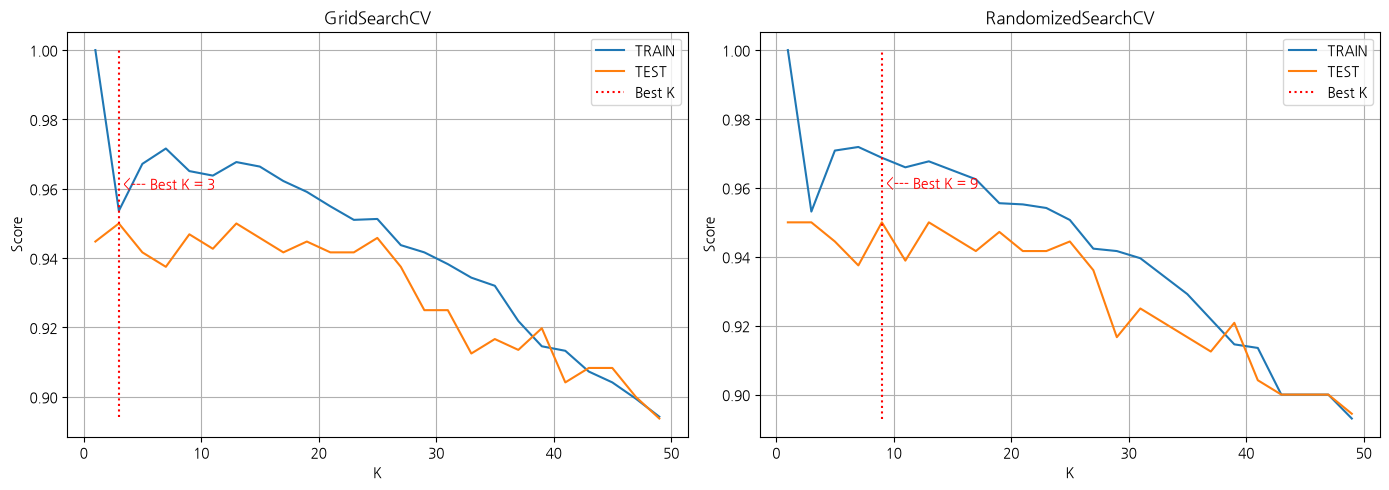

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, best_k, best_score, title in zip(axes, [gs_totalDF, rs_totalDF],[gs_best_k, rs_best_k],
                                             [gs_best_score, rs_best_score],['GridSearchCV', 'RandomizedSearchCV']):
    min_y = df['train_score'].min()
    max_y = df['train_score'].max()
    ax.plot(df['K'], df['train_score'], label='TRAIN')
    ax.plot(df['K'], df['test_score'],  label='TEST')
    ax.vlines(best_k, min_y, max_y, colors='red', linestyles='dotted', label='Best K')
    ax.text(best_k, best_score + 0.01, f' <--- Best K = {int(best_k)}', c='red')
    ax.set_title(title)
    ax.set_xlabel('K')
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

- **[6]예측 및 평가**
    * 테스트 데이터 기반 예측
    * 사용자 입__력 기반 예측

In [54]:
from sklearn.metrics import classification_report, accuracy_score

y_pre = gs_best.predict(x_test)

print(f"정확도(Accuracy): {accuracy_score(y_test, y_pre):.4f}\n")
print(f'{classification_report(y_test, y_pre)}\n')

정확도(Accuracy): 1.0000

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10
   Virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30




In [56]:
y_pre = rs_best.predict(x_test)

print(f"정확도(Accuracy): {accuracy_score(y_test, y_pre):.4f}\n")
print(f'{classification_report(y_test, y_pre)}\n')

정확도(Accuracy): 1.0000

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10
   Virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30




In [52]:
user_input = input("붓꽃 정보 입력(예: 0.12 0.08 1.23 1.44): ").split(" ")
newDF = pd.DataFrame([[float(x) for x in user_input]], columns=x_train.columns)

y_pre = gs_best.predict(newDF)
print(y_pre)

['Setosa']


In [55]:
user_input = input("붓꽃 정보 입력(예: 0.12 0.08 1.23 1.44): ").split(" ")
newDF = pd.DataFrame([[float(x) for x in user_input]], columns=x_train.columns)

y_pre = rs_best.predict(newDF)
print(y_pre)

['Setosa']
